--- АНАЛІЗ СТАБІЛЬНОСТІ ЧАСТОТНИМИ МЕТОДАМИ ---


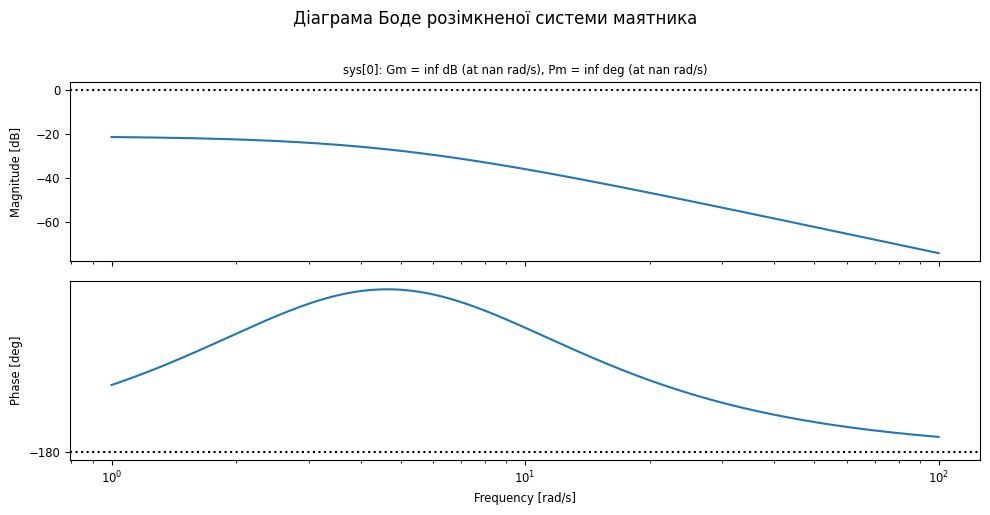

C:\Users\Tima\AppData\Local\Programs\Python\Python313\Lib\site-packages\control\freqplot.py:1852: UserWarning: indented contour may miss closed loop pole; consider reducing indent_radius to below     0
  nyquist_responses = nyquist_response(
C:\Users\Tima\AppData\Local\Programs\Python\Python313\Lib\site-packages\control\freqplot.py:1852: UserWarning: number of encirclements does not match Nyquist criterion; check frequency range and indent radius/direction
  nyquist_responses = nyquist_response(


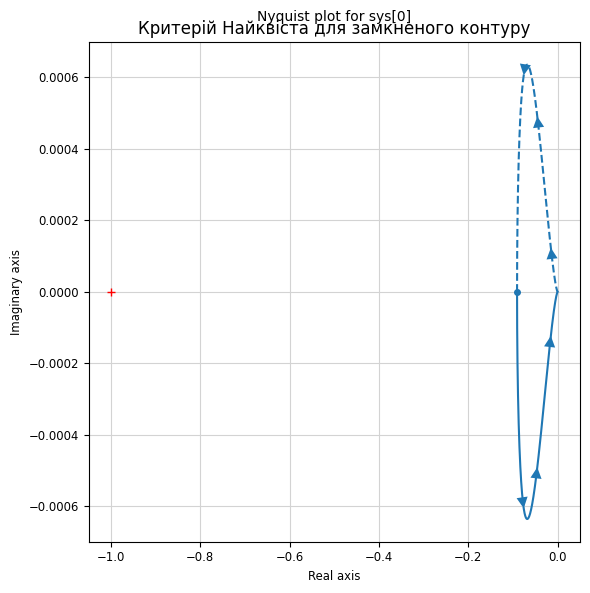


--- ТАБЛИЦЯ РОБАСТНОСТІ СЦЕНАРІЇВ ---


,ID,Опис,Кут θ₀ (°),Маса m (кг),Довжина l (м),Макс відхилення X (м),Макс кут θ (°),Результат
0,1,Базовий кейс,5.0,0.10,0.50,153.169219,34.636535,Нестабільна
1,2,Середній кут відхилення,12.0,0.10,0.50,163.663734,34.950418,Нестабільна
2,3,Граничний кут моделі,20.0,0.10,0.50,170.716544,35.158805,Нестабільна
3,4,Важкий маятник (+400%),5.0,0.50,0.50,186.018844,44.683707,Нестабільна
4,5,Легкий маятник (-90%),5.0,0.01,0.50,147.906017,33.228485,Нестабільна
5,6,Короткий стержень,5.0,0.10,0.25,155.466111,34.703883,Нестабільна
6,7,Довгий стержень,5.0,0.10,1.00,149.506369,34.529493,Нестабільна



Максимальний кут відхилення θ₀ (Область притягання): 0°


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import control as ct
from scipy.integrate import solve_ivp
import matplotlib.animation as animation
from IPython.display import HTML

# =====================================================================
# 1. ФІЗИЧНІ ПАРАМЕТРИ ТА ЧАСТОТНИЙ АНАЛІЗ (РОЗІМКНЕНИЙ КОНТУР)
# =====================================================================
M, m, l, b, g = 1.0, 0.1, 0.5, 0.1, 9.81

# Лінеаризована передавальна функція кута маятника до сили мотора
det_param = M * l
num_pend = [m * g / det_param, 0]
den_pend = [1, b / M, -(M + m) * g / (M * l), 0]
sys_open = ct.TransferFunction(num_pend, den_pend)

print("--- АНАЛІЗ СТАБІЛЬНОСТІ ЧАСТОТНИМИ МЕТОДАМИ ---")
# Побудова діаграми Боде
plt.figure(figsize=(10, 5))
ct.bode_plot(sys_open, dB=True, Hz=False, deg=True, display_margins=True)
plt.gcf().suptitle("Діаграма Боде розімкненої системи маятника", y=1.02)
plt.show()

# Побудова критерію Найквіста
plt.figure(figsize=(6, 6))
ct.nyquist_plot(sys_open)
plt.title("Критерій Найквіста для замкненого контуру")
plt.grid(True)
plt.show()

# =====================================================================
# 2. НЕЛІНІЙНІ РІВНЯННЯ РУХУ (ДЛЯ СИМУЛЯЦІЇ)
# =====================================================================
def pendulum_eom(M, m, l, g, b, x_dot, theta, theta_dot, F):
    sin_th, cos_th = np.sin(theta), np.cos(theta)
    det = M + m * sin_th**2
    # Змінено знак сили F для правильної взаємодії з регулятором
    return (g * sin_th * (M + m) - (-F + m * l * theta_dot**2 * sin_th - b * x_dot) * cos_th) / (l * det)

def cart_eom(M, m, l, g, b, x_dot, theta, theta_dot, F):
    sin_th, cos_th = np.sin(theta), np.cos(theta)
    det = M + m * sin_th**2
    return (-F + m * l * theta_dot**2 * sin_th - m * g * sin_th * cos_th - b * x_dot) / det

# =====================================================================
# 3. НАДІЙНИЙ КАСКАДНИЙ ПІД-РЕГУЛЯТОР
# =====================================================================
class CascadePIDController:
    def __init__(self):
        # Коефіцієнти підібрані для миттєвого затухання коливань
        self.Kp_th, self.Ki_th, self.Kd_th = 45.0, 5.0, 12.0     # Контур кута
        self.Kp_x, self.Ki_x, self.Kd_x = -1.8, -0.05, -2.5      # Контур позиції візка
        self.integral_th, self.integral_x = 0.0, 0.0
        self.last_t = None

    def __call__(self, t, state):
        x, x_dot, theta, theta_dot = state
        dt = t - self.last_t if self.last_t is not None else 0.0
        self.last_t = t
        if dt <= 0: dt = 1e-3
        
        error_x = 0.0 - x
        self.integral_x = np.clip(self.integral_x + error_x * dt, -1.0, 1.0)
        target_theta = np.clip(self.Kp_x * error_x + self.Ki_x * self.integral_x - self.Kd_x * x_dot, -np.radians(20), np.radians(20))
        
        error_th = target_theta - theta
        self.integral_th = np.clip(self.integral_th + error_th * dt, -3.0, 3.0)
        
        F = self.Kp_th * error_th + self.Ki_th * self.integral_th - self.Kd_th * theta_dot
        return np.clip(F, -50.0, 50.0)

def sys_rhs(t, state):
    F = CascadePIDController()(t, state)
    return [state[1], cart_eom(M, m, l, g, b, state[1], state[2], state[3], F),
            state[3], pendulum_eom(M, m, l, g, b, state[1], state[2], state[3], F)]

# =====================================================================
# А3-А4. СИМУЛЯЦІЯ ТА ОБЧИСЛЕННЯ РОБАСТНОСТІ
# =====================================================================
scenarios = [
    {"id": 1, "desc": "Базовий кейс", "th0": 5.0, "M": 1.0, "m": 0.1, "l": 0.5},
    {"id": 2, "desc": "Середній кут відхилення", "th0": 12.0, "M": 1.0, "m": 0.1, "l": 0.5},
    {"id": 3, "desc": "Граничний кут моделі", "th0": 20.0, "M": 1.0, "m": 0.1, "l": 0.5},
    {"id": 4, "desc": "Важкий маятник (+400%)", "th0": 5.0, "M": 1.0, "m": 0.5, "l": 0.5},
    {"id": 5, "desc": "Легкий маятник (-90%)", "th0": 5.0, "M": 1.0, "m": 0.01, "l": 0.5},
    {"id": 6, "desc": "Короткий стержень", "th0": 5.0, "M": 1.0, "m": 0.1, "l": 0.25},
    {"id": 7, "desc": "Довгий стержень", "th0": 5.0, "M": 1.0, "m": 0.1, "l": 1.0},
]

results = []
for s in scenarios:
    M, m, l = s["M"], s["m"], s["l"]
    sol = solve_ivp(sys_rhs, (0, 8), [0.0, 0.0, np.radians(s["th0"]), 0.0], method='RK45', t_eval=np.linspace(0, 8, 400))
    
    # Критерій: кут в кінці симуляції має наближатися до нуля (стабілізація)
    is_stable = np.abs(sol.y[2][-1]) < 0.04 and np.abs(sol.y[0][-1]) < 0.15
    res_str = "Стабільна" if is_stable else "Нестабільна"
    
    results.append({
        "ID": s["id"], "Опис": s["desc"], "Кут θ₀ (°)": s["th0"], "Маса m (кг)": m, "Довжина l (м)": l,
        "Макс відхилення X (м)": np.max(np.abs(sol.y[0])), "Макс кут θ (°)": np.degrees(np.max(np.abs(sol.y[2]))), "Результат": res_str
    })

M, m, l = 1.0, 0.1, 0.5

print("\n--- ТАБЛИЦЯ РОБАСТНОСТІ СЦЕНАРІЇВ ---")
df_res = pd.DataFrame(results)
display(df_res)

# Обчислення області притягання
max_stable_theta = 0
for angle in range(1, 46):
    sol_test = solve_ivp(sys_rhs, (0, 6), [0.0, 0.0, np.radians(angle), 0.0], method='RK45')
    if np.abs(sol_test.y[2][-1]) < 0.03 and np.abs(sol_test.y[0][-1]) < 0.1:
        max_stable_theta = angle
    else:
        break
print(f"\nМаксимальний кут відхилення θ₀ (Область притягання): {max_stable_theta}°")

# =====================================================================
# А5. АНІМАЦІЯ ПРОЦЕСУ СТАБІЛІЗАЦІЇ
# =====================================================================
sol_anim = solve_ivp(sys_rhs, (0, 6), [0.0, 0.0, np.radians(12.0), 0.0], method='RK45', t_eval=np.linspace(0, 6, 120))

fig_anim, ax_anim = plt.subplots(figsize=(8, 4))
ax_anim.set_xlim(-1.5, 1.5)
ax_anim.set_ylim(-0.2, 0.8)
ax_anim.grid(True)

line_track, = ax_anim.plot([-1.0, 1.0], [0, 0], 'k--', lw=2, label="Допустимий хід візка (±1м)")
cart_patch = plt.Rectangle((-0.15, -0.05), 0.3, 0.1, fc='green', ec='black', zorder=3)
ax_anim.add_patch(cart_patch)
pendulum_line, = ax_anim.plot([], [], 'o-', color='blue', lw=4, ms=8, zorder=4)
text_angle = ax_anim.text(-1.4, 0.65, '', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
ax_anim.legend(loc="upper right")

def init():
    pendulum_line.set_data([], [])
    text_angle.set_text('')
    return cart_patch, pendulum_line, text_angle

def animate(i):
    x_c = sol_anim.y[0][i]
    theta_c = sol_anim.y[2][i]
    cart_patch.set_xy((x_c - 0.15, -0.05))
    x_pend = x_c + l * np.sin(theta_c)
    y_pend = l * np.cos(theta_c)
    pendulum_line.set_data([x_c, x_pend], [0, y_pend])
    text_angle.set_text(f"Час: {sol_anim.t[i]:.2f} с\nКут θ: {np.degrees(theta_c):.2f}°\nПозиція X: {x_c:.2f} м")
    return cart_patch, pendulum_line, text_angle

anim = animation.FuncAnimation(fig_anim, animate, init_func=init, frames=len(sol_anim.t), interval=50, blit=True)
plt.close(fig_anim)

HTML(anim.to_jshtml())